<div style="border:solid green 2px; padding: 20px">
<b>Iteration - 2</b><br>
<b>Reviewer’s comments</b><br>

Hello Alexandria!,
  
I am Alexangel, your reviewer in this second iteration,
  
Another project successfully completed - well done! 🏆 Your consistent effort and progress are truly commendable.

Our team is here to help you keep pushing forward and honing your skills as you advance through the program.

My comments are marked as `Reviewer's comment, Iteration 2`. You can contact me via Tripleten Hub for further feedback. This information is described below.

**What Was Great**:
- Excellent job on following the structure of the project.

**Tips for Future Projects**:
- Consider adding brief comments after every result to make your work even more integral.

</div>

-------------------------------------------------------------------------------------------------------------

***Name of the reviewer***: Alexangel Bracho

***Reviewer’s Tripleten Hub link*** : [reviewer's link](https://hub.tripleten.com/u/5eb4617a)

-------------------------------------------------------------------------------------------------------------


<div style="border:solid green 2px; padding: 20px">

👋 **Hello! I'm Dot, your AI reviewer.**

I've completed the first pass of your code review. Below, you'll find my comments and suggestions for improvement.

**What should you do next?**

1. **Review:** check my comments in the notebook below.
2. **Decide:**
* **Agree with the feedback?** Great! Update your code accordingly.
* **Disagree or think it's a mistake?** No problem! You can keep your code exactly as it is.


3. **Resubmit:** Send your project back. **Your next iteration will be reviewed by a human expert**, whether you made changes or not.

-------------------------------------------------------------------------------------------------------------
Please find my comments below—**I kindly ask that you do not move, modify, or delete them**.

You can find my comments highlighted in green, yellow, or red boxes like this:

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Success. Everything is done succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Remarks. Some recommendations.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Needs fixing. The block requires some corrections.
</div>



# Video Game Sales Analysis Project
## Project Overview

In this project, you'll analyze video game sales data to identify patterns that determine a game's success. Working as an analyst for the online store Ice, you'll use this information to help plan future advertising campaigns.

## Environment Setup and Required Libraries

In [1]:
# Import all required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
import math as mt
import seaborn as sns

## Step 1: Loading and Initial Data Exploration

First, let's load our dataset and examine its basic properties:

In [2]:
# Load the dataset

games = pd.read_csv("/datasets/games.csv")

In [3]:
# Display basic information about the dataset

games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [4]:
# Check for duplicate entries

# running a boolean filter to create a dataframe of duplicates
duplicates_df = games[games.duplicated()]

# counting the duplicates in the resulting dataframe
duplicates_df.count()

Name               0
Platform           0
Year_of_Release    0
Genre              0
NA_sales           0
EU_sales           0
JP_sales           0
Other_sales        0
Critic_Score       0
User_Score         0
Rating             0
dtype: int64

### Key Questions to Answer:
- What's the total number of records in our dataset?
- What data types are present in each column?
- Are there any obvious issues with the data?
- Do we see any immediate patterns or anomalies?

- What's the total number of records in our dataset? : 16,715 entries
- What data types are present in each column? : object, float64
- Are there any obvious issues with the data? : critic_score, user_score, and rating have around 50 percent missing values
- Do we see any immediate patterns or anomalies? : No , and there are no duplicates in the dataset

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

This section lists key questions (record count, data types, and any obvious issues/anomalies), but there isn’t a short written summary answering them. Consider adding a brief paragraph synthesizing what you saw in `info()` (rows/columns, types, missing values, duplicates) and what that implies for the next cleaning steps.

</div>


## Step 2: Data Preparation

### 2.1 Standardizing Column Names

In [5]:
# Convert column names to lowercase

games.columns = games.columns.str.lower()

In [6]:
# Verify the changes

games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Nice workflow: you load the data, run initial checks, standardize column names to lowercase, and then verify the result. That verification step is a great habit for reproducible analysis.

</div>


### 2.2 Data Type Conversion

In [7]:
# Check current data types

games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [8]:
# Make changes to data types if necessary
# Describe the columns where the data types have been changed and why.

# changing year_of_realease to Int64
games['year_of_release'] = games['year_of_release'].astype('Int64')

# changing user_score to float64 because it needs to be a numerical type
# First we need to handle the tbd values so I will replace those with NaN for now using the replace method

games['user_score'] = games['user_score'].replace('tbd', 'NaN')
games['user_score'] = games['user_score'].astype(float)

# visual exploration to make sure that everything is going as planned
games.info()

# checking the rating object type
#games['rating'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Good start converting `year_of_release` and `user_score`, but please document your handling of `tbd` explicitly in the narrative. Also, replacing `'tbd'` with the string `'NaN'` is ambiguous—consider replacing with an actual missing value so it’s clear you’re treating `tbd` as unknown rather than a real numeric score.

</div>


In [9]:
# Pay attention to the abbreviation TBD (to be determined). Specify how you intend to handle such cases.

I chose to handle the tbd values by replacing them with NaN because they are currently unknown and should be treated like missing or unknown data. The convention for representing
missing or unknown data is to use NaN.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Recurring note (see above): this cell is currently empty, but the assignment asks you to explicitly state how you handle `tbd` values and why that choice is appropriate for later analysis.

</div>


### 2.3 Handling Missing Values

In [10]:
# Examine missing values

games.info()

games.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

In [11]:
# Calculate percentage of missing values

# problem does not specify if it wants the individual columns or just the total of all so I will do both
# first the individual calculations

# name column
names_percent_missing = ( games['name'].isna().sum() / games['name'].size ) * 100
print(f"Names_percent_missing : {names_percent_missing}")

# year_of_release column
yor_percent_missing = ( games['year_of_release'].isna().sum() / games['year_of_release'].size ) * 100
print(f"Year_of_release_percent_missing : {yor_percent_missing}")


# genre column
genre_percent_missing = ( games['genre'].isna().sum() / games['genre'].size ) * 100
print(f"Genre_percent_missing : {genre_percent_missing}")

# critic_score column
critic_score_percent_missing = ( games['critic_score'].isna().sum() / games['critic_score'].size ) * 100
print(f"Critic_score_percent_missing : {critic_score_percent_missing}")

# user_score column
user_score_percent_missing = ( games['user_score'].isna().sum() / games['user_score'].size ) * 100
print(f"User_score_percent_missing : {user_score_percent_missing}")

# rating column
rating_score_percent_missing = ( games['rating'].isna().sum() / games['rating'].size ) * 100
print(f"Rating_score_percent_missing : {rating_score_percent_missing}")


# dataframe total
games_missing = games.isna().sum()
games_total = games.shape[0]
games_percentage_missing = games_missing / games_total * 100

print(f"Games_percent_missing: \n\n {games_percentage_missing}")


Names_percent_missing : 0.011965300628178284
Year_of_release_percent_missing : 1.609332934489979
Genre_percent_missing : 0.011965300628178284
Critic_score_percent_missing : 51.31917439425665
User_score_percent_missing : 54.59168411606342
Rating_score_percent_missing : 40.478612025127134
Games_percent_missing: 

 name                0.011965
platform            0.000000
year_of_release     1.609333
genre               0.011965
na_sales            0.000000
eu_sales            0.000000
jp_sales            0.000000
other_sales         0.000000
critic_score       51.319174
user_score         54.591684
rating             40.478612
dtype: float64


In [12]:
# Analyze patterns in missing values

# using groupby to analyze if critic_score, user_score, and rating is affected by name, platform, year_of_release and genre

print(games['critic_score'].isna().groupby(games['name']).sum())
print()

# The platforms that have the most significant amounts of NaN values are 3DS, DS, GBA, N64, PC, PS, PS2, PS3, PSP, PSV, SAT, SNES, X360 . With the exception of PSV, the majority of these are older consoles.
missing_platform_critic_score = games['critic_score'].isna().groupby(games['platform']).sum()
total_platform_critic_score = games['critic_score'].groupby(games['platform']).size()
percentage_platform_critic_score = missing_platform_critic_score / total_platform_critic_score * 100
print(missing_platform_critic_score)
print()
print(percentage_platform_critic_score)
print()


# 1998 - 2016 are where majority of the NaN values are. I think there is an increase in NaN because companies are attempting to get more feedback, so with the increase in polling for these critic scores,
# there is also an increase in missing critic scores. Population increase, linear error increase also.
missing_year_of_release_critic_score = games['critic_score'].isna().groupby(games['year_of_release']).sum()
total_year_of_release_critic_score = games['critic_score'].groupby(games['year_of_release']).size()
percentage_year_of_release_critic_score = missing_year_of_release_critic_score / total_year_of_release_critic_score * 100
print(missing_year_of_release_critic_score)
print()
print(percentage_year_of_release_critic_score)
print()


# There are NaN in all genres but the top 4 are Action, Misc, Role-Playing, Sports. I can not discern any pattern here
print(games['critic_score'].isna().groupby(games['genre']).sum())
print()
print()
print()

print(games['user_score'].isna().groupby(games['name']).sum())
print()

# These all have about 300 or more NaN values : 3DS, DS, GBA, N64, PS, PS2, PS3, PSP, PSV, Wii, X360. With the exception of PSV, the majority of these are older consoles.
print(games['user_score'].isna().groupby(games['platform']).sum())
print()

# 300 or more : 1998 - 2016 . Companies are polling more scores, so there are more missing scores. More data means linear increase in missing data also.
print(games['user_score'].isna().groupby(games['year_of_release']).sum())
print()

# Top 4 are Action, Misc, Role-Playing, Sports
print(games['user_score'].isna().groupby(games['genre']).sum())
print()
print()
print()

print(games['rating'].isna().groupby(games['name']).sum())
print()

# These all have about 300 or more NaN values : 3DS, DS, GBA, N64, PS, PS2, PS3, PSP, PSV, Wii. With the exception of PSV, the majority of these are older consoles.
print(games['rating'].isna().groupby(games['platform']).sum())
print()

# 300 or more : 1998 - 2016 . Companies are polling more scores, so there are more missing scores. More data means linear increase in missing data also.
print(games['rating'].isna().groupby(games['year_of_release']).sum())
print()

# Top 4 are : Action, Misc, Role-Playing, Sports
print(games['rating'].isna().groupby(games['genre']).sum())
print()

name
 Beyblade Burst                 1
 Fire Emblem Fates              1
 Frozen: Olaf's Quest           2
 Haikyu!! Cross Team Match!     1
 Tales of Xillia 2              0
                               ..
thinkSMART: Chess for Kids      1
uDraw Studio                    0
uDraw Studio: Instant Artist    1
wwe Smackdown vs. Raw 2006      1
¡Shin Chan Flipa en colores!    1
Name: critic_score, Length: 11559, dtype: int64

platform
2600     133
3DO        3
3DS      352
DC        38
DS      1434
GB        98
GBA      384
GC       108
GEN       29
GG         1
N64      319
NES       98
NG        12
PC       259
PCFX       1
PS       997
PS2      863
PS3      511
PS4      140
PSP      747
PSV      310
SAT      173
SCD        6
SNES     239
TG16       2
WS         6
Wii      735
WiiU      57
X360     346
XB        99
XOne      78
Name: critic_score, dtype: int64

platform
2600    100.000000
3DO     100.000000
3DS      67.692308
DC       73.076923
DS       66.666667
GB      100.000000
GBA

In [13]:
# Handle missing values based on analysis

# Your code here to handle missing values according to your strategy

games_after_2001 = games[games['year_of_release'] >= 2001]
print(games_after_2001.shape)

# dataframe total
games_after_2001_missing = games_after_2001.isna().sum()
games_after_2001_total = games_after_2001.shape[0]
games_after_2001_percentage_missing = games_after_2001_missing / games_after_2001_total * 100

print(f"Games_percent_missing: \n\n {games_after_2001_percentage_missing}")

# creating a separate subset of data that only includes rows where critic_score is not missing

games_has_critic_score = games[games['critic_score'].notnull()]
games_has_critic_score

# creating other subsets here that I may need to use

(14120, 11)
Games_percent_missing: 

 name                0.000000
platform            0.000000
year_of_release     0.000000
genre               0.000000
na_sales            0.000000
eu_sales            0.000000
jp_sales            0.000000
other_sales         0.000000
critic_score       45.155807
user_score         48.555241
rating             32.613314
dtype: float64


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
...,...,...,...,...,...,...,...,...,...,...,...
16696,Breach,PC,2011,Shooter,0.01,0.00,0.00,0.00,61.0,5.8,T
16697,Bust-A-Move 3000,GC,2003,Puzzle,0.01,0.00,0.00,0.00,53.0,NaN,E
16698,Mega Brain Boost,DS,2008,Puzzle,0.01,0.00,0.00,0.00,48.0,NaN,E
16702,STORM: Frontline Nation,PC,2011,Strategy,0.00,0.01,0.00,0.00,60.0,7.2,E10+


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

This part is labeled as “handle missing values,” but the main actions are filtering by year and creating subsets. Consider clearly defining a missing-data strategy per key column (e.g., what you do with missing `year_of_release`, `critic_score`, `user_score`, `rating`, and missing `name/genre`) and then implement those decisions (fill/drop/leave as missing) so it’s clear what dataset each later analysis is based on.

</div>


In [14]:
# Why do you think the values are missing? Give possible reasons.
# Explain why you filled in the missing values as you did or why you decided to leave them blank.

Based on my analysis, it is best to cutoff the data at the year 2001 and only use the more recent data for our future prognosis of the year 2017's expectations
Also, we are going to use different subsets of the data for different questions/tasks. For example, for the sales by platform/genre analysis I will use the fulll filtered dataset
( all rows , missing reviews are fine ), and for the critic score vs sales analysis, I will use only the rows where critic scores exist.
I think that it is because back in the day they were not focused on getting feedback from users because they did not have systems in place like they do nowadays to learn and leverage marketing decisions from them.
In other words, back in the day they did not have systems in place to get feedback like they do today. In summary, I have chosen to make several different subsets of the data. As far as actually handling missing data, there is not much that I can do because it is possible that if I fill the values it will affect the data too much by skewing the results.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

You explain possible reasons values are missing, which is helpful, but the notebook also asks you to justify your specific treatment decisions (what you filled vs. left missing vs. removed). Consider adding a short rationale tied directly to the strategy you applied for `year_of_release`, scores, ratings, and the small number of missing `name/genre` values.

</div>


### 2.4 Calculate Total Sales

In [15]:
# Calculate total sales across all regions and put them in a different column

games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']
games

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN,0.01


# Step 3: Analyzing Video Game Sales Data

## 3.1 Temporal Analysis of Game Releases
Let's first examine the distribution of game releases across different years to understand our data's coverage and significance:

In [16]:
# Create a DataFrame with game releases by year

games_by_year = games.groupby('year_of_release').size()
games_by_year = games_by_year.to_frame(name = 'size').reset_index()
games_by_year

,year_of_release,size
0,1980,9
1,1981,46
2,1982,36
3,1983,17
4,1984,14
5,1985,14
6,1986,21
7,1987,16
8,1988,15
9,1989,17


<AxesSubplot:xlabel='year_of_release'>

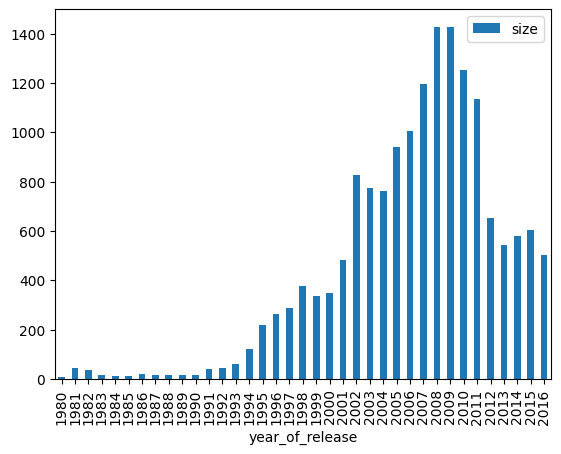

In [17]:
# Visualize the distribution of games across years

games_by_year.plot(kind = 'bar', x = 'year_of_release', y = 'size')

# Years of significant increase : 2002, 2005, 2008
# Years of significant decrease : 2012

In [18]:
# Display summary statistics for each year

games.groupby('year_of_release')['total_sales'].describe()

,count,mean,std,min,25%,50%,75%,max
year_of_release,,,,,,,,
1980,9.0,1.264444,1.383547,0.23,0.3400,0.770,1.1500,4.31
1981,46.0,0.775652,0.783019,0.13,0.3125,0.465,0.9525,4.50
1982,36.0,0.802222,1.257910,0.14,0.3350,0.540,0.7800,7.81
1983,17.0,0.988235,0.838825,0.16,0.4000,0.770,1.1300,3.20
1984,14.0,3.596429,7.200795,0.27,1.1300,1.485,2.0900,28.31
1985,14.0,3.853571,10.510376,0.02,0.4650,1.015,1.4550,40.24
1986,21.0,1.765714,1.328001,0.30,1.1500,1.360,2.2000,6.50
1987,16.0,1.356250,1.225174,0.07,0.4550,0.885,2.2125,4.38
1988,15.0,3.147333,4.414414,0.03,0.9700,1.510,3.1450,17.28


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 2</b> <a class="tocSkip"></a>

Good job with removing the `games_relevant` dataframe in this section. 

</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

This section uses `games_relevant` before it is defined later, which breaks a top-to-bottom run of the notebook. Consider either defining the filtered dataset earlier (before this cell) or computing these per-year stats from `games` here and introducing filtering afterward when you justify the “relevant years” choice.

</div>


### Questions to Consider:
- Which years show significant numbers of game releases?
- Are there any notable trends or patterns in the number of releases?
- Is there enough recent data to make predictions for 2017?

## 3.2 Platform Sales Analysis Over Time

Now let's analyze how sales vary across platforms and years:

In [19]:
# Calculate total sales by platform and year

total_sales_by_platform_year_s = games.groupby(['platform', 'year_of_release'])['total_sales'].sum()
total_sales_by_platform_year_df = total_sales_by_platform_year_s.to_frame(name = 'total_sales_sum').reset_index()
total_sales_by_platform_year_df

,platform,year_of_release,total_sales_sum
0,2600,1980,11.38
1,2600,1981,35.68
2,2600,1982,28.88
3,2600,1983,5.84
4,2600,1984,0.27
...,...,...,...
233,XB,2008,0.18
234,XOne,2013,18.96
235,XOne,2014,54.07
236,XOne,2015,60.14


In [20]:
# Create a heatmap of platform sales over time

# pivot table

pivot_table = total_sales_by_platform_year_df.pivot('platform', 'year_of_release', 'total_sales_sum')
pivot_table

year_of_release,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
platform,,,,,,,,,,,,,,,,,,,,,
2600,11.38,35.68,28.88,5.84,0.27,0.45,0.67,1.94,0.74,0.63,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3DO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3DS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,63.20,51.36,56.57,43.76,27.78,15.14
DC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.02,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DS,NaN,NaN,NaN,NaN,NaN,0.02,NaN,NaN,NaN,NaN,...,146.94,145.31,119.54,85.02,26.18,11.01,1.54,NaN,NaN,NaN
GB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.43,64.97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GBA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<AxesSubplot:xlabel='year_of_release', ylabel='platform'>

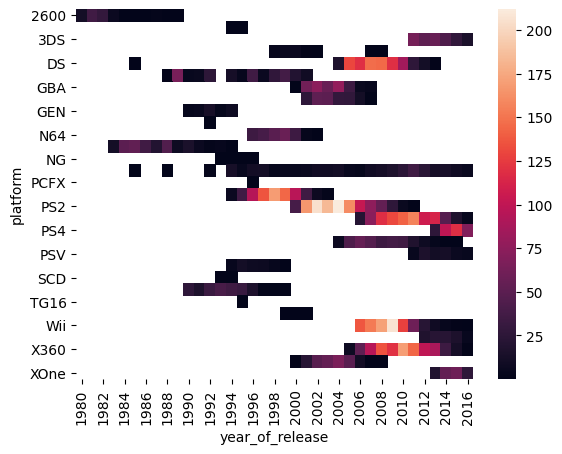

In [21]:
sns.heatmap(pivot_table)

In [22]:
total_sales_by_platform_year_df

,platform,year_of_release,total_sales_sum
0,2600,1980,11.38
1,2600,1981,35.68
2,2600,1982,28.88
3,2600,1983,5.84
4,2600,1984,0.27
...,...,...,...
233,XB,2008,0.18
234,XOne,2013,18.96
235,XOne,2014,54.07
236,XOne,2015,60.14


In [23]:
# Identify platforms with declining sales

# first choose the dataframe that we are going to use
#total_sales_by_platform_year_df

# adding yoy_growth column
total_sales_by_platform_year_df['yoy_growth'] = total_sales_by_platform_year_df.groupby('platform')['total_sales_sum'].transform(lambda x: x.pct_change())
total_sales_by_platform_year_df

# groupby platform and aggregate with mean()

total_sales_by_platform_year_df['yoy_growth_mean'] = total_sales_by_platform_year_df.groupby('platform')['yoy_growth'].transform(lambda x: x.mean())

# filter to only show declining

platforms_declining_sales_df = total_sales_by_platform_year_df[total_sales_by_platform_year_df['yoy_growth_mean'] < 0]

# groupby to condense rows

platforms_declining_sales_s = platforms_declining_sales_df.groupby('platform')['yoy_growth_mean'].mean()

# cleaning it up

platform_declining_sales_df = platforms_declining_sales_s.to_frame(name = 'yoy_growth_mean').reset_index()
platform_declining_sales_df

,platform,yoy_growth_mean
0,3DS,-0.226505
1,DC,-0.132316
2,GC,-0.182787
3,N64,-0.285417
4,SCD,-0.760000
5,SNES,-0.153097
6,WS,-0.054987
7,Wii,-0.381412
8,WiiU,-0.181504


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 2</b> <a class="tocSkip"></a>

Good update with this section `Identify platforms with declining sales`.

</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

This task is left blank. Consider adding code that identifies platforms with a clear decline over your selected period (e.g., based on negative year-over-year changes or near-zero sales by the final year) and then briefly summarize which platforms are shrinking and which are growing.

</div>


### Questions to Consider:
- Which platforms show consistent sales over time?
- Can you identify platforms that have disappeared from the market?
- What's the typical lifecycle of a gaming platform?

## 3.3 Determining Relevant Time Period

Based on your analysis above, determine the appropriate time period for predicting 2017 sales:

In [24]:
# Your code here to filter the dataset to relevant years
# Example:
# relevant_years = [XXXX, XXXX, XXXX] # Replace with your chosen years
# df_relevant = df[df['year_of_release'].isin(relevant_years)]


relevant_years = [2012, 2013, 2014, 2015, 2016]
games_relevant = games[games['year_of_release'].isin(relevant_years)]

# Justify your choice with data
# I chose these years because recent mean relevant. We need the most recent data in order to make the best prognosis from trends of the most recent years. This is the best
# way to ensure that we are capturing market trends in our analysis

### Document Your Decision:
- What years did you select and why?
- How does this period reflect current market conditions?
- What factors influenced your decision?

## 3.4 Platform Performance Analysis

Using your selected time period, let's analyze platform performance:

In [25]:
# Analyze platform sales trends

# getting the dataframe that we will use for analysis

#games_relevant

# chain groupby and sum, this returns a series after the sum() call

games_relevant_s = games_relevant.groupby('platform')['total_sales'].sum()

# lets see what we are working with
#games_relevant_s

# to_frame() and reset_index()

games_platform_performance_df = games_relevant_s.to_frame(name = 'total_sales_sum').reset_index()
games_platform_performance_df

,platform,total_sales_sum
0,3DS,194.61
1,DS,12.55
2,PC,62.65
3,PS3,288.79
4,PS4,314.14
5,PSP,11.19
6,PSV,49.18
7,Wii,35.37
8,WiiU,82.19
9,X360,236.54


In [26]:
# Sort platforms by total sales

games_platform_performance_df = games_platform_performance_df.sort_values(by = 'total_sales_sum' , ascending = False)

In [27]:
# Visualize top platforms
# Calculate year-over-year growth for each platform
# Your code here to calculate and visualize platform growth rates

# visualization
# games_platform_performance_df.plot(kind = 'bar', x = 'platform', y = 'total_sales_sum')

# calculate year-over-year growth for each platform
games_pct_change_s = games_relevant.groupby(['platform', 'year_of_release'])['total_sales'].sum()

# visualization
games_pct_change_df = games_pct_change_s.to_frame(name = 'total_sales_sum').reset_index()


games_pct_change_df['yoy_growth'] = games_pct_change_df.groupby('platform')['total_sales_sum'].transform(lambda x: x.pct_change())
games_pct_change_df

# These platforms had decreases in yoy_growth : 3DS, DS, PC, PS3, PSP, PSV, X360
# These platforms had both increases and decreases in yoy_growth : Wii & WiiU
# These platforms had siginificant growth in yoy_growth : PS4 & XONE 

,platform,year_of_release,total_sales_sum,yoy_growth
0,3DS,2012,51.36,NaN
1,3DS,2013,56.57,0.101441
2,3DS,2014,43.76,-0.226445
3,3DS,2015,27.78,-0.365174
4,3DS,2016,15.14,-0.455004
5,DS,2012,11.01,NaN
6,DS,2013,1.54,-0.860127
7,PC,2012,23.22,NaN
8,PC,2013,12.38,-0.466839
9,PC,2014,13.28,0.072698


## 3.5 Sales Distribution Analysis

Let's examine the distribution of sales across platforms:

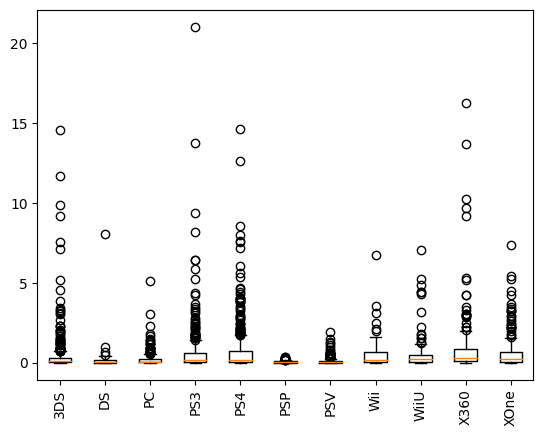

In [28]:
# Create box plot of sales by platform

# first bring in the dataframe that we are going to use
# games_relevant

# You need total_sales grouped by platform
games_platform_sales_s = games_relevant.groupby('platform')
#games_platform_sales_s

# Matplotlib's .boxplot() works well here, but you'll need to prepare the data as a list of arrays, one per platform
# Can you think of how you'd extract the total_sales values for each platform separately? Hint: a loop or a list comprehension over the unique platforms could help! 😊

# this gives us a list of arrays one per platform.

sales_data = [group['total_sales'].values for name, group in games_platform_sales_s]

# we want to save the platform names separately for labeling the chart

platform_names = [name for name, group in games_platform_sales_s]

# creating the chart

plt.boxplot( sales_data, labels = platform_names)
plt.xticks(rotation = 90)
plt.show()

Analysis : 

- The outlier dots represent all of the individual game sales figures that are outside the normal distribution range for PS4 sales. Obviously all of those outlier sales are successes because they represent higher numbers of sales than the normal distribution of sales. The spread is larger than most of the other platforms, with the exception of X360. A larger spread means greater inconsistency which means that there are outliers. In this case the outliers are above the spread which represents more platform sales.
- PS4's growth rate was positive in recent years. When compared to X360, X360 had decreases in sales and PS4 had tremendous increases and when comparing to PS3, PS4's sales greatly outperformed PS3. PS4 achieved a similar spread to X360 and in a shorter time, and in terms of the platform's lifecycle it means that PS4 still has a lot of room to grow.
- Because it was just released and even though it looks promising, their is not enough data to back its initial promising results. So it could be said that PS4's great results are due to some other uncontrollable factor and that there is not enough historical data to confidently predict whether PS4's growth will be sustained long-term.
- It tells me that PS4 has great potential moving forward. I think that this makes PS4 look like a good bet for a game developer to release a new title because in 2015, they had a total sales sum of 118.90 million and in 2014 their year over year growth was 285%.


In [29]:
# Calculate detailed statistics for each platform

games_relevant.groupby('platform')['total_sales'].describe()

,count,mean,std,min,25%,50%,75%,max
platform,,,,,,,,
3DS,396.0,0.491439,1.387161,0.01,0.0400,0.11,0.3125,14.60
DS,31.0,0.404839,1.439245,0.01,0.0200,0.05,0.1850,8.06
PC,250.0,0.250600,0.494640,0.01,0.0300,0.08,0.2400,5.14
PS3,493.0,0.585781,1.462855,0.01,0.0500,0.20,0.6100,21.05
PS4,392.0,0.801378,1.609456,0.01,0.0600,0.20,0.7300,14.63
PSP,173.0,0.064682,0.071296,0.01,0.0200,0.03,0.0900,0.36
PSV,411.0,0.119659,0.203011,0.01,0.0200,0.05,0.1200,1.96
Wii,54.0,0.655000,1.165447,0.01,0.0625,0.18,0.6875,6.76
WiiU,147.0,0.559116,1.058836,0.01,0.0800,0.22,0.5250,7.09


## 3.6 Review Score Impact Analysis

Select a popular platform and analyze how reviews affect sales:

In [30]:
# Choose a popular platform based on your previous analysis

I think that PS4 would be a great choice to pick because they had the largest increase in year over year growth. They also have a high total sales sum for the year of 2015.  
In addition the platform is young and even though it is a new platform it does have historical data of relevant previous generations that can provide important insight as to how the PS4 platform may behave in future years.

In [31]:
# Create scatter plots for both critic and user scores

# first choose the correct dataframe to use
#games_relevant

# we need only PS4 platform

games_ps4 = games_relevant[games_relevant['platform'] == 'PS4']
#games_ps4

# only keep rows where the score actually exists

games_ps4_has_critic_score_df = games_ps4[games_ps4['critic_score'].notnull()]
games_ps4_has_user_score_df = games_ps4[games_ps4['user_score'].notnull()]



<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 2</b> <a class="tocSkip"></a>

Great update with not filling missing review scores with `zero`.

</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Filling missing review scores with 0 will bias both the scatter plots and correlation results because 0 is a valid score, not “missing.” Consider filtering to rows where the relevant score is present (or dropping missing values pairwise for each correlation) so the relationships you measure reflect real reviews.

</div>


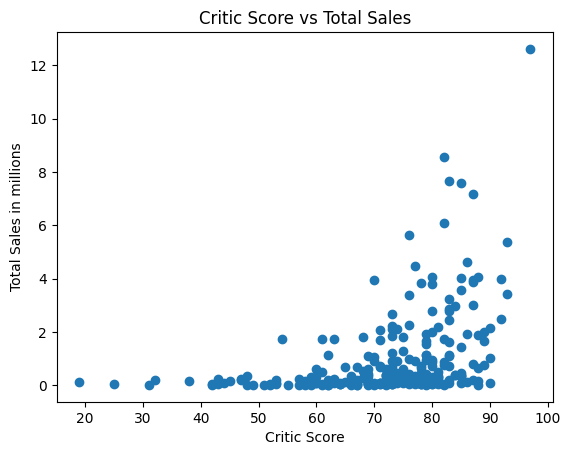

0.40656790206178095


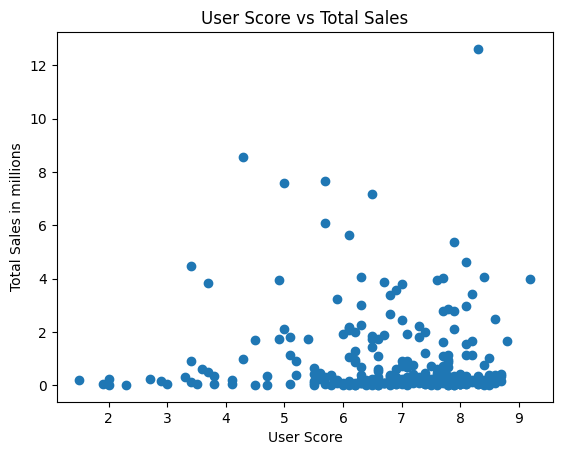

-0.031957110204556376


In [32]:
# Critic Scores

plt.scatter(games_ps4_has_critic_score_df['critic_score'], games_ps4_has_critic_score_df['total_sales'])
plt.xlabel('Critic Score')
plt.ylabel('Total Sales in millions')
plt.title('Critic Score vs Total Sales')
plt.show()

# calculate correlations
print(games_ps4_has_critic_score_df['critic_score'].corr(games_ps4_has_critic_score_df['total_sales']))


# User Scores

plt.scatter(games_ps4_has_user_score_df['user_score'], games_ps4_has_user_score_df['total_sales'])
plt.xlabel('User Score')
plt.ylabel('Total Sales in millions')
plt.title('User Score vs Total Sales')
plt.show()


# Calculate correlations
print(games_ps4_has_user_score_df['user_score'].corr(games_ps4_has_user_score_df['total_sales']))

## 3.7 Cross-Platform Comparison

Compare sales performance of games across different platforms:

In [33]:
# Find games released on multiple platforms

# first we choose the dataframe
games_relevant

#boxplot

# first need to find games that were released on multiple platforms.

games_games_s = games_relevant.groupby('name')['platform'].count()
games_games_df = games_games_s.to_frame(name = 'platform_count').reset_index()
games_games_df

# only want games that appear on more than one platform
games_games_df = games_games_df[games_games_df['platform_count'] > 1]
#games_games_df

# adding the total sales column
games_games_df1 = games_relevant[games_relevant['name'].isin(games_games_df['name'])]
#games_games_df1

games_games_df1

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
34,Call of Duty: Black Ops II,PS3,2012,Shooter,4.99,5.73,0.65,2.42,83.0,5.3,M,13.79
35,Call of Duty: Black Ops II,X360,2012,Shooter,8.25,4.24,0.07,1.12,83.0,4.8,M,13.68
...,...,...,...,...,...,...,...,...,...,...,...,...
16672,Metal Gear Solid V: The Definitive Experience,XOne,2016,Action,0.01,0.00,0.00,0.00,NaN,NaN,M,0.01
16691,Dynasty Warriors: Eiketsuden,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16692,Metal Gear Solid V: Ground Zeroes,PC,2014,Action,0.00,0.01,0.00,0.00,80.0,7.6,M,0.01
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01


In [34]:
# consider creating a game-by-platform pivot ( for multi-platform titles) and comparing platform columns for those same titles

pivot_table_1 = games_games_df1.pivot_table(values = 'total_sales', columns = 'platform', index = 'name')
pivot_table_1

platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
name,,,,,,,,,,,
Frozen: Olaf's Quest,0.59,0.51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014 FIFA World Cup Brazil,NaN,NaN,NaN,0.61,NaN,NaN,NaN,NaN,NaN,0.43,NaN
3rd Super Robot Wars Z Jigoku Hen,NaN,NaN,NaN,0.23,NaN,NaN,0.19,NaN,NaN,NaN,NaN
3rd Super Robot Wars Z: Tengoku-Hen,NaN,NaN,NaN,0.15,NaN,NaN,0.19,NaN,NaN,NaN,NaN
7 Days to Die,NaN,NaN,NaN,NaN,0.14,NaN,NaN,NaN,NaN,NaN,0.05
...,...,...,...,...,...,...,...,...,...,...,...
Zone of the Enders HD Collection,NaN,NaN,NaN,0.42,NaN,NaN,NaN,NaN,NaN,0.20,NaN
Zoo Tycoon (2013),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.09,0.36
Zumba Fitness Core,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.07,NaN,0.05,NaN


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 2</b> <a class="tocSkip"></a>

Good update creating a `game-by-platform` pivot.

</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The goal here is to compare sales of the *same games* across platforms. Grouping by platform and plotting distributions still mixes many different titles together, so it’s not a true side-by-side comparison for identical games. Consider creating a game-by-platform pivot (for multi-platform titles) and comparing platform columns for those same titles.

</div>


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

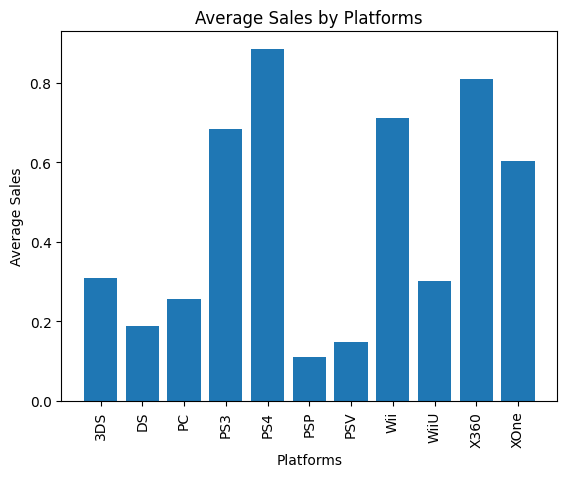

In [35]:
# Compare sales across platforms for these games
# Your code here to analyze and visualize cross-platform performance

# first what dataframe are we going to use
#games_games_df1

# groupby and aggregate

games_games_s2 = games_games_df1.groupby('platform')['total_sales'].mean()

# bar chart


plt.bar(games_games_s2.index, games_games_s2.values)
plt.xlabel('Platforms')
plt.ylabel('Average Sales')
plt.title('Average Sales by Platforms')
plt.xticks(rotation = 90)

## 3.8 Genre Analysis

Finally, let's examine the distribution of games by genre:

In [36]:
# Analyze genre performance
# first decide what dataframe we are going to use in this case we are using the unfiltered dataframe that has all values

games_relevant

# groupby
games_genre_s = games_relevant.groupby('genre')['total_sales'].sum()
games_genre_df = games_genre_s.to_frame(name = 'total_sales_sum').reset_index()
games_genre_df

,genre,total_sales_sum
0,Action,441.12
1,Adventure,29.43
2,Fighting,44.49
3,Misc,85.04
4,Platform,61.00
5,Puzzle,4.89
6,Racing,53.50
7,Role-Playing,192.80
8,Shooter,304.73
9,Simulation,35.12


In [37]:
# Sort genres by total sales

games_genre_df = games_genre_df.sort_values(by = 'total_sales_sum' , ascending = False)
games_genre_df

,genre,total_sales_sum
0,Action,441.12
8,Shooter,304.73
7,Role-Playing,192.80
10,Sports,181.07
3,Misc,85.04
4,Platform,61.00
6,Racing,53.50
2,Fighting,44.49
9,Simulation,35.12
1,Adventure,29.43


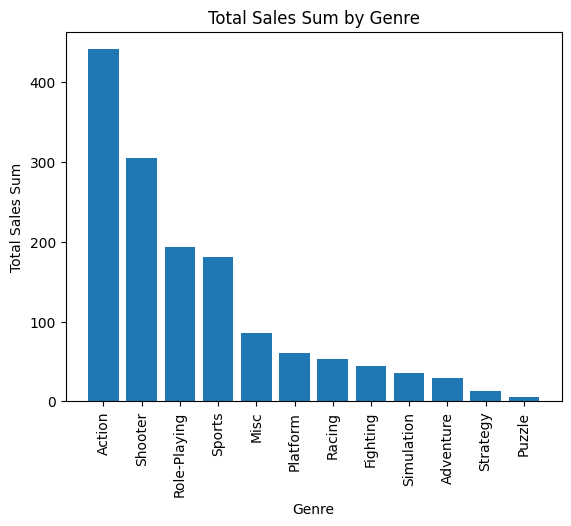

In [38]:
# Visualize genre distribution

# creating a bar chart

plt.bar(games_genre_df['genre'], games_genre_df['total_sales_sum'])
plt.xlabel('Genre')
plt.ylabel('Total Sales Sum')
plt.title('Total Sales Sum by Genre')
plt.xticks(rotation = 90)
plt.show()

In [39]:
# Calculate market share for each genre

games_genre_df['market_share'] = games_genre_df['total_sales_sum'] / games_genre_df['total_sales_sum'].sum() * 100
#print(games_genre_df['market_share'].sum())
games_genre_df

,genre,total_sales_sum,market_share
0,Action,441.12,30.495047
8,Shooter,304.73,21.066276
7,Role-Playing,192.80,13.328448
10,Sports,181.07,12.517542
3,Misc,85.04,5.878896
4,Platform,61.00,4.216988
6,Racing,53.50,3.698506
2,Fighting,44.49,3.075636
9,Simulation,35.12,2.427879
1,Adventure,29.43,2.034524


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Strong genre section: you aggregated sales by genre, sorted the results, visualized them, and added a market share calculation. This is a clear and well-structured approach for summarizing performance by category.

</div>


### Key Questions for Genre Analysis:
- Which genres consistently perform well?
- Are there any genres showing recent growth or decline?
- How does the average performance vary across genres?

# Step 4: Regional Market Analysis and User Profiles

In this section, we will analyze the gaming market characteristics across three major regions: North America (NA), Europe (EU), and Japan (JP). Our analysis will focus on platform preferences, genre popularity, and the impact of ESRB ratings in each region.

## 4.1 Regional Platform Analysis

Let's begin by examining platform performance across different regions:

In [40]:
# Function to analyze platform performance by region

def analyze_platform_performance_by_region(region):
    # code to execute
    dataframe_s = games_relevant.groupby('platform')[region].sum()
    dataframe_df = dataframe_s.to_frame(name = region+'_sum').reset_index()
    return dataframe_df

regions_list = ['eu_sales', 'na_sales', 'jp_sales', 'other_sales']

games_region_platform_performance_df = analyze_platform_performance_by_region(regions_list[0])

for region in regions_list[1:] :
    games_region_platform_performance_df = games_region_platform_performance_df.merge(analyze_platform_performance_by_region(region), on = 'platform', how = 'left')

games_region_platform_performance_df['eu_sales_market_share'] = games_region_platform_performance_df['eu_sales_sum']/games_region_platform_performance_df['eu_sales_sum'].sum() * 100
games_region_platform_performance_df['na_sales_market_share'] = games_region_platform_performance_df['na_sales_sum']/games_region_platform_performance_df['na_sales_sum'].sum() * 100
games_region_platform_performance_df['jp_sales_market_share'] = games_region_platform_performance_df['jp_sales_sum']/games_region_platform_performance_df['jp_sales_sum'].sum() * 100
games_region_platform_performance_df['ot_sales_market_share'] = games_region_platform_performance_df['other_sales_sum']/games_region_platform_performance_df['other_sales_sum'].sum() * 100
games_region_platform_performance_df

,platform,eu_sales_sum,na_sales_sum,jp_sales_sum,other_sales_sum,eu_sales_market_share,na_sales_market_share,jp_sales_market_share,ot_sales_market_share
0,3DS,42.64,55.31,87.79,8.87,8.413243,9.359189,45.586250,5.680072
1,DS,3.53,4.59,3.72,0.71,0.696500,0.776689,1.931665,0.454662
2,PC,37.76,19.12,0.00,5.77,7.450377,3.235359,0.000000,3.694928
3,PS3,106.86,103.38,35.29,43.26,21.084409,17.493274,18.324852,27.702357
4,PS4,141.09,108.74,15.96,48.35,27.838286,18.400257,8.287465,30.961834
5,PSP,0.42,0.13,10.47,0.17,0.082870,0.021998,5.436702,0.108863
6,PSV,11.36,10.98,21.04,5.80,2.241427,1.857962,10.925330,3.714139
7,Wii,11.92,17.45,3.39,2.61,2.351920,2.952773,1.760307,1.671363
8,WiiU,25.13,38.10,13.01,5.95,4.958368,6.447028,6.755634,3.810195
9,X360,74.52,140.05,1.57,20.40,14.703445,23.698326,0.815246,13.063525


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

You’ve calculated regional platform totals and identified leaders, but the prompt also asks for market share differences by region. Consider computing each platform’s share within each region (percent of regional sales) and then summarizing how NA/EU/JP differ (not only which platform is #1, but how concentrated the market is and how rankings shift).

</div>


In [41]:
# Analyze each region

games_region_platform_performance_na_df = games_region_platform_performance_df.sort_values(ascending = False, by = 'na_sales_sum')
print(games_region_platform_performance_na_df.head())

games_region_platform_performance_eu_df = games_region_platform_performance_df.sort_values(ascending = False, by = 'eu_sales_sum')
print(games_region_platform_performance_eu_df.head())

games_region_platform_performance_jp_df = games_region_platform_performance_df.sort_values(ascending = False, by = 'jp_sales_sum')
print(games_region_platform_performance_jp_df.head())

games_region_platform_performance_ot_df = games_region_platform_performance_df.sort_values(ascending = False, by = 'other_sales_sum')
print(games_region_platform_performance_ot_df.head())

   platform  eu_sales_sum  na_sales_sum  jp_sales_sum  other_sales_sum  \
9      X360         74.52        140.05          1.57            20.40   
4       PS4        141.09        108.74         15.96            48.35   
3       PS3        106.86        103.38         35.29            43.26   
10     XOne         51.59         93.12          0.34            14.27   
0       3DS         42.64         55.31         87.79             8.87   

    eu_sales_market_share  na_sales_market_share  jp_sales_market_share  \
9               14.703445              23.698326               0.815246   
4               27.838286              18.400257               8.287465   
3               21.084409              17.493274              18.324852   
10              10.179156              15.757145               0.176550   
0                8.413243               9.359189              45.586250   

    ot_sales_market_share  
9               13.063525  
4               30.961834  
3               27.7

### Cross-Regional Platform Comparison

Let's create a comparative analysis of platform performance across regions:

<AxesSubplot:title={'center':'Comparative Platform Analysis'}, xlabel='platform', ylabel='Sales in millions'>

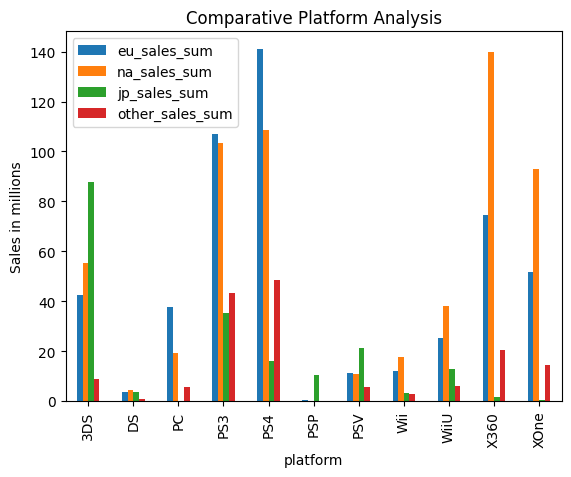

In [42]:
# Create a comparative platform analysis

games_region_platform_performance_df.plot(kind = 'bar', 
                                          x = 'platform',
                                          y = ['eu_sales_sum', 'na_sales_sum', 'jp_sales_sum', 'other_sales_sum'],
                                          title = 'Comparative Platform Analysis', 
                                          ylabel = 'Sales in millions'
                                         )

In [43]:
games_region_platform_performance_df

,platform,eu_sales_sum,na_sales_sum,jp_sales_sum,other_sales_sum,eu_sales_market_share,na_sales_market_share,jp_sales_market_share,ot_sales_market_share
0,3DS,42.64,55.31,87.79,8.87,8.413243,9.359189,45.586250,5.680072
1,DS,3.53,4.59,3.72,0.71,0.696500,0.776689,1.931665,0.454662
2,PC,37.76,19.12,0.00,5.77,7.450377,3.235359,0.000000,3.694928
3,PS3,106.86,103.38,35.29,43.26,21.084409,17.493274,18.324852,27.702357
4,PS4,141.09,108.74,15.96,48.35,27.838286,18.400257,8.287465,30.961834
5,PSP,0.42,0.13,10.47,0.17,0.082870,0.021998,5.436702,0.108863
6,PSV,11.36,10.98,21.04,5.80,2.241427,1.857962,10.925330,3.714139
7,Wii,11.92,17.45,3.39,2.61,2.351920,2.952773,1.760307,1.671363
8,WiiU,25.13,38.10,13.01,5.95,4.958368,6.447028,6.755634,3.810195
9,X360,74.52,140.05,1.57,20.40,14.703445,23.698326,0.815246,13.063525


In [44]:
games_region_platform_performance_df['total_sales_sum'] = games_region_platform_performance_df['eu_sales_sum'] + games_region_platform_performance_df['na_sales_sum'] + games_region_platform_performance_df['jp_sales_sum'] + games_region_platform_performance_df['other_sales_sum']

In [45]:
games_region_platform_performance_df

,platform,eu_sales_sum,na_sales_sum,jp_sales_sum,other_sales_sum,eu_sales_market_share,na_sales_market_share,jp_sales_market_share,ot_sales_market_share,total_sales_sum
0,3DS,42.64,55.31,87.79,8.87,8.413243,9.359189,45.586250,5.680072,194.61
1,DS,3.53,4.59,3.72,0.71,0.696500,0.776689,1.931665,0.454662,12.55
2,PC,37.76,19.12,0.00,5.77,7.450377,3.235359,0.000000,3.694928,62.65
3,PS3,106.86,103.38,35.29,43.26,21.084409,17.493274,18.324852,27.702357,288.79
4,PS4,141.09,108.74,15.96,48.35,27.838286,18.400257,8.287465,30.961834,314.14
5,PSP,0.42,0.13,10.47,0.17,0.082870,0.021998,5.436702,0.108863,11.19
6,PSV,11.36,10.98,21.04,5.80,2.241427,1.857962,10.925330,3.714139,49.18
7,Wii,11.92,17.45,3.39,2.61,2.351920,2.952773,1.760307,1.671363,35.37
8,WiiU,25.13,38.10,13.01,5.95,4.958368,6.447028,6.755634,3.810195,82.19
9,X360,74.52,140.05,1.57,20.40,14.703445,23.698326,0.815246,13.063525,236.54


In [46]:
games_region_platform_performance_top5_df = games_region_platform_performance_df.sort_values(ascending = False, by = 'total_sales_sum')
games_region_platform_performance_top5_df

,platform,eu_sales_sum,na_sales_sum,jp_sales_sum,other_sales_sum,eu_sales_market_share,na_sales_market_share,jp_sales_market_share,ot_sales_market_share,total_sales_sum
4,PS4,141.09,108.74,15.96,48.35,27.838286,18.400257,8.287465,30.961834,314.14
3,PS3,106.86,103.38,35.29,43.26,21.084409,17.493274,18.324852,27.702357,288.79
9,X360,74.52,140.05,1.57,20.40,14.703445,23.698326,0.815246,13.063525,236.54
0,3DS,42.64,55.31,87.79,8.87,8.413243,9.359189,45.586250,5.680072,194.61
10,XOne,51.59,93.12,0.34,14.27,10.179156,15.757145,0.176550,9.138064,159.32
8,WiiU,25.13,38.10,13.01,5.95,4.958368,6.447028,6.755634,3.810195,82.19
2,PC,37.76,19.12,0.00,5.77,7.450377,3.235359,0.000000,3.694928,62.65
6,PSV,11.36,10.98,21.04,5.80,2.241427,1.857962,10.925330,3.714139,49.18
7,Wii,11.92,17.45,3.39,2.61,2.351920,2.952773,1.760307,1.671363,35.37
1,DS,3.53,4.59,3.72,0.71,0.696500,0.776689,1.931665,0.454662,12.55


<AxesSubplot:title={'center':'Comparative Platform Analysis'}, xlabel='platform', ylabel='Sales in millions'>

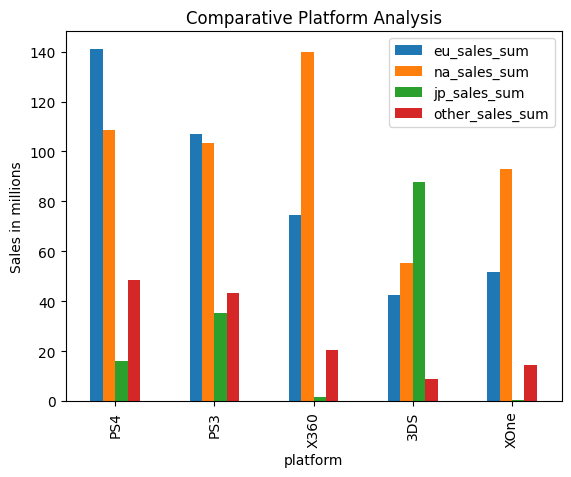

In [47]:
# Visualize cross-regional comparison for top platforms

games_region_platform_performance_top5_df = games_region_platform_performance_top5_df.head()

games_region_platform_performance_top5_df.plot(kind = 'bar', 
                                          x = 'platform',
                                          y = ['eu_sales_sum', 'na_sales_sum', 'jp_sales_sum', 'other_sales_sum'],
                                          title = 'Comparative Platform Analysis', 
                                          ylabel = 'Sales in millions'
                                         )

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 2</b> <a class="tocSkip"></a>

Great upadte with sorting your results by `total_sales_sum`.

</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The “top platforms” subset uses the first five rows of an unsorted table (`[0:5]`), which may not represent the actual top 5 and can make the plot misleading. Consider sorting by a clear criterion (e.g., a chosen region’s sales or total across regions) and then selecting `.head(5)`.

</div>


## 4.2 Regional Genre Analysis

Now let's examine genre preferences across regions:

In [48]:
# Function to analyze genre performance by region

def analyze_genre_performance_by_region(region):
    # code to execute
    dataframe_s = games_relevant.groupby('genre')[region].sum()
    dataframe_df = dataframe_s.to_frame(name = region+'_sum').reset_index()
    return dataframe_df

regions_list = ['eu_sales', 'na_sales', 'jp_sales', 'other_sales']

games_region_genre_performance_df = analyze_genre_performance_by_region(regions_list[0])

for region in regions_list[1:] :
    games_region_genre_performance_df = games_region_genre_performance_df.merge(analyze_genre_performance_by_region(region), on = 'genre', how = 'left')

games_region_genre_performance_df

,genre,eu_sales_sum,na_sales_sum,jp_sales_sum,other_sales_sum
0,Action,159.34,177.84,52.80,51.14
1,Adventure,9.46,8.92,8.24,2.81
2,Fighting,10.79,19.79,9.44,4.47
3,Misc,26.32,38.19,12.86,7.67
4,Platform,21.41,25.38,8.63,5.58
5,Puzzle,1.40,1.13,2.14,0.22
6,Racing,27.29,17.22,2.50,6.49
7,Role-Playing,48.53,64.00,65.44,14.83
8,Shooter,113.47,144.77,9.23,37.26
9,Simulation,14.55,7.97,10.41,2.19


### Cross-Regional Genre Comparison

Let's compare genre preferences across regions:

In [49]:
games_region_genre_performance_df['total_sales_sum'] = games_region_genre_performance_df['eu_sales_sum'] + games_region_genre_performance_df['na_sales_sum'] + games_region_genre_performance_df['jp_sales_sum'] + games_region_genre_performance_df['other_sales_sum']

In [50]:
games_region_genre_performance_top5_df = games_region_genre_performance_df.sort_values(ascending = False, by = 'total_sales_sum')

<AxesSubplot:title={'center':'Comparative Genre Analysis'}, xlabel='genre', ylabel='Sales in millions'>

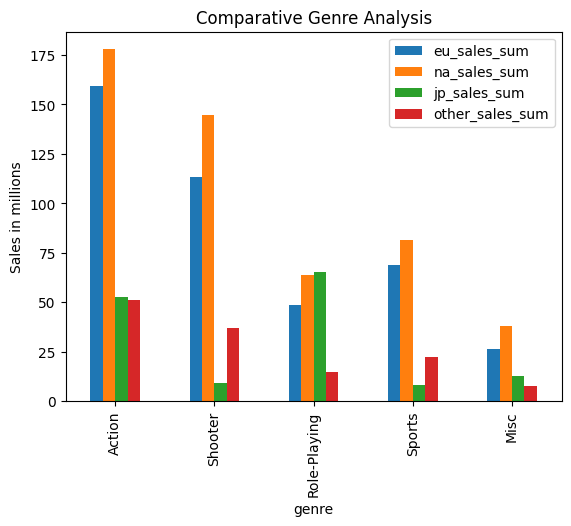

In [51]:
# Create a comparative genre analysis

games_region_genre_performance_top5_df = games_region_genre_performance_top5_df.head()

games_region_genre_performance_top5_df.plot(kind = 'bar', 
                                          x = 'genre',
                                          y = ['eu_sales_sum', 'na_sales_sum', 'jp_sales_sum', 'other_sales_sum'],
                                          title = 'Comparative Genre Analysis', 
                                          ylabel = 'Sales in millions'
                                         )

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

This section asks for the top five genres per region and an explanation of differences. The bar chart of totals is useful, but consider explicitly extracting the top 5 genres for NA/EU/JP (and reporting their shares) and adding a short interpretation of how regional preferences differ.

</div>


## 4.3 ESRB Rating Impact Analysis

Finally, let's examine how ESRB ratings affect sales in each region:

In [52]:
# Function to analyze ESRB rating impact

def analyze_rating_performance_by_region(region):
    # code to execute
    dataframe_s = games_relevant.groupby('rating')[region].sum()
    dataframe_df = dataframe_s.to_frame(name = region+'_sum').reset_index()
    return dataframe_df

regions_list = ['eu_sales', 'na_sales', 'jp_sales', 'other_sales']

games_region_rating_performance_df = analyze_rating_performance_by_region(regions_list[0])

for region in regions_list[1:] :
    games_region_rating_performance_df = games_region_rating_performance_df.merge(analyze_rating_performance_by_region(region), on = 'rating', how = 'left')

games_region_rating_performance_df

,rating,eu_sales_sum,na_sales_sum,jp_sales_sum,other_sales_sum
0,E,113.03,114.37,28.33,31.44
1,E10+,55.37,75.70,8.19,16.23
2,M,193.96,231.57,21.20,63.38
3,T,52.96,66.02,26.02,17.94


<AxesSubplot:title={'center':'Comparative Rating Analysis'}, xlabel='rating', ylabel='Sales in millions'>

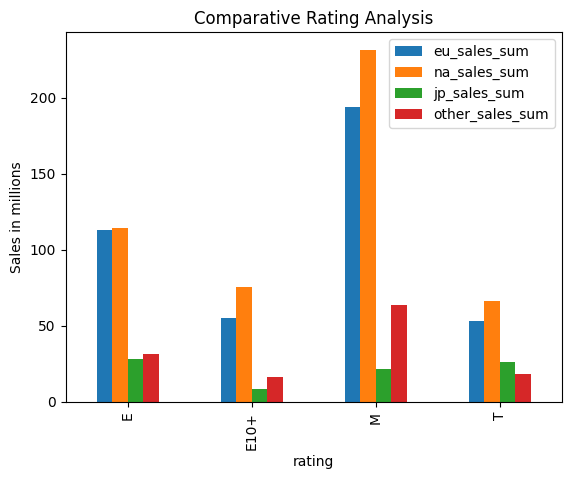

In [53]:
# Analyze ESRB impact for each region

games_region_rating_performance_df.plot(kind = 'bar', 
                                          x = 'rating',
                                          y = ['eu_sales_sum', 'na_sales_sum', 'jp_sales_sum', 'other_sales_sum'],
                                          title = 'Comparative Rating Analysis', 
                                          ylabel = 'Sales in millions'
                                         )

# Step 5 : Hypothesis Tests

—Average user ratings of the Xbox One and PC platforms are the same.

—Average user ratings for the Action and Sports genres are different.

Set the *alpha* threshold value yourself.

Explain:

—How you formulated the null and alternative hypotheses

—What criteria you used to test the hypotheses~~,~~ and why


1 : Average user ratings of the Xbox One and PC platforms are the same

- Null hypothesis : Average user ratings of the Xbox One and PC platformas are the same
- Alternative hypothesis : Average user ratings of the Xbox One and PC platforms are different

2 : Average user ratings for the Action and Sports genres are different

- Null hypothesis : Average user ratings for the Action and Sports genres are different
- Alternative hypothesis : Average user ratings for the Action and Sports genres are the same

3 : Alpha threshold :

- I have chosen an alpha threshold of 0.5

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 2</b> <a class="tocSkip"></a>

Good update with establishing the null hypothesis and the alternative hypothesis for both cases.

</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Your hypotheses need a bit of cleanup for consistency: typically H0 states “no difference / equal means,” and H1 states “there is a difference.” In particular, the Action vs Sports null/alternative are flipped. Also, please explicitly choose and state an alpha level (e.g., 0.05) here before running the tests.

</div>


In [54]:
games_relevant

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,NaN,14.60
34,Call of Duty: Black Ops II,PS3,2012,Shooter,4.99,5.73,0.65,2.42,83.0,5.3,M,13.79
...,...,...,...,...,...,...,...,...,...,...,...,...
16703,Strawberry Nauts,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16707,Aiyoku no Eustia,PSV,2014,Misc,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01


In [55]:
games_relevant['platform'].unique()

array(['PS3', 'X360', 'PS4', '3DS', 'DS', 'XOne', 'WiiU', 'Wii', 'PC',
       'PSV', 'PSP'], dtype=object)

In [56]:
# filter the test sets

# hypothesis 1

xone_df = games_relevant[games_relevant['platform'] == 'XOne']
pc_df = games_relevant[games_relevant['platform'] == 'PC']

# hypothesis 2

action_df = games_relevant[games_relevant['genre'] == 'Action']
sports_df = games_relevant[games_relevant['genre'] == 'Sports']

# filtering out NaN

# hypothesis 1
xone_df = xone_df[xone_df['user_score'].notnull()]
pc_df = pc_df[pc_df['user_score'].notnull()]

# hypothesis 2

action_df = action_df[action_df['user_score'].notnull()]
sports_df = sports_df[sports_df['user_score'].notnull()]


In [57]:
# Test the hypotheses 1

alpha = 0.05
results = st.ttest_ind(xone_df['user_score'], pc_df['user_score'], equal_var = False)

print('p-value:', results.pvalue)
if results.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")

# Test the hypotheses 2

alpha = 0.05
results = st.ttest_ind(action_df['user_score'], sports_df['user_score'], equal_var = False)

print('p-value:', results.pvalue)
if results.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")

p-value: 0.5489537965134912
We can't reject the null hypothesis
p-value: 4.24307776572644e-20
We reject the null hypothesis


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 2</b> <a class="tocSkip"></a>

Good update with obtaining non-null values for the results.

</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Both t-tests return `p-value = NaN`, which usually means the samples contain missing/non-numeric values and/or one of the groups is empty due to filtering. Consider (1) verifying your filter values match the dataset (e.g., platform is shown as `XOne`, not `XONE`), and (2) dropping rows with missing `user_score` in each group before testing. It may also be helpful to decide whether to assume equal variances (`equal_var`) based on a variance comparison.

</div>


# Step 6. Write a general conclusion
